# VMC Hand Stiffness Model — Supplementary Validation

Validates the three VMC stiffness formulations for the full five-finger hand:
- **Joint-space** (`stiffness2jointspace`): virtual springs in joint-angle coordinates
- **Task-space** (`stiffness2taskspace`): virtual springs in Cartesian coordinates (6 attachment points)
- **Mixed-space** (`stiffness2mixedspace`): joint-space and task-space springs simultaneously

Experiments for each model:
1. Tip stiffness eigenvalues and contact forces across all five fingers
2. Finite-difference stiffness validation (1st-order Salisbury vs. 2nd-order CCT)
3. Stiffness gradient-descent convergence
4. Reference gradient-descent convergence
5. Stiffness inversion accuracy

In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, os.path.join('..'))
from plot_config import COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size

FONT_SIZE = 18
set_font_size(FONT_SIZE)
plt.rcParams['savefig.bbox'] = 'tight'
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

OUT_DIR = os.path.join('outputs', 'stiffness_model')
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
np.random.seed(42)

from StiffnessModelHand.stiffness2jointspace import tip_stiffness_JointSpace, FINGERS_ALL
from StiffnessModelHand.stiffness2taskspace  import tip_stiffness_TaskSpace
from StiffnessModelHand.stiffness2mixedspace import tip_stiffness_MixedSpace
from KinematicsHand.FK_Hand import (
    FK_motor2thumb, FK_motor2finger, FK_motor2spread,
    FK_motor2thumbPos, FK_motor2fingerPos, FK_motor2palm
)

# Shared motor-angle state: thumb and index flexed (13-DoF hand)
Q_REF  = np.zeros(13)
Q_BASE = np.zeros(13)
Q_BASE[2] = np.deg2rad(30.0)   # thumb MCP
Q_BASE[3] = np.deg2rad(20.0)   # thumb IP
Q_BASE[5] = np.deg2rad(30.0)   # index MCP
Q_BASE[6] = np.deg2rad(20.0)   # index PIP

K_JOINT = 0.4   # joint stiffness [N·m/rad]
K_TASK  = 200.0 # task stiffness  [N/m]
MAX_ITERS = 30000
LOG_EVERY = 5000
EPS_VALS  = [1e-3, 1e-4, 1e-5]
N_FD      = 6
F_DES     = np.array([0.0, 0.02, 0.03])
TEST_FINGERS = ['thumb', 'index']

ALL_POINTS  = ['thumb', 'index', 'middle', 'ring', 'pinky', 'palm']

K_joint_dict = {
    'thumb':         K_JOINT * np.eye(4),
    'spread_index':  K_JOINT * np.eye(1),
    'spread_middle': K_JOINT * np.eye(1),
    'spread_ring':   K_JOINT * np.eye(1),
    'spread_pinky':  K_JOINT * np.eye(1),
    'index':         K_JOINT * np.eye(3),
    'middle':        K_JOINT * np.eye(3),
    'ring':          K_JOINT * np.eye(3),
    'pinky':         K_JOINT * np.eye(3),
}

# Build initial theta_ref_deg from q_ref (ordered to match K_joint_dict)
def _build_theta_ref_deg(q, K_jd):
    parts = []
    for group in K_jd.keys():
        if group == 'thumb':
            parts.append(FK_motor2thumb(q))
        elif group.startswith('spread_'):
            parts.append(np.array([FK_motor2spread(q, group[7:])]))
        else:
            parts.append(FK_motor2finger(q, group))
    return np.degrees(np.concatenate(parts))

THETA_REF_DEG = _build_theta_ref_deg(Q_REF, K_joint_dict)

print('Building Jacobians/Hessians (may take ~30 s) ...')
t0 = time.time()
model_js = tip_stiffness_JointSpace(mode='full')
model_ts = tip_stiffness_TaskSpace(mode='full')
model_ms = tip_stiffness_MixedSpace(mode='full')
print(f'Done in {time.time() - t0:.1f} s')

# Task-space reference dict and stiffness dict
d_ref_ts   = {p: model_ts._pos(p, Q_REF) for p in ALL_POINTS}
K_task_ts  = {p: K_TASK * np.eye(3) for p in ALL_POINTS}

# Mixed-space references
d_ref_ms   = {p: model_ms._pos(p, Q_REF) for p in ALL_POINTS}
K_task_ms  = {p: K_TASK * np.eye(3) for p in ALL_POINTS}

Building Jacobians/Hessians (may take ~30 s) ...
All Jacobians initialized.
All Hessians initialized.
All Jacobians initialized.
All Hessians initialized.
All Jacobians initialized.
All Hessians initialized.
Done in 51.9 s


## 1 — Tip Stiffness Eigenvalues and Contact Forces

Eigenvalues of the $3 \times 3$ Cartesian tip stiffness matrix and the contact force vector at all five fingertips, for each model formulation.

In [3]:
eig_results = {'JointSpace': {}, 'TaskSpace': {}, 'MixedSpace': {}}
frc_results = {'JointSpace': {}, 'TaskSpace': {}, 'MixedSpace': {}}

for finger in FINGERS_ALL:
    K_js = model_js.tip_stiffness(finger, Q_BASE, K_joint_dict)
    f_js = model_js.tip_force(finger, Q_BASE, THETA_REF_DEG, K_joint_dict)
    eig_results['JointSpace'][finger] = np.linalg.eigvalsh(K_js)
    frc_results['JointSpace'][finger] = f_js

    K_ts_ = model_ts.tip_stiffness(finger, Q_BASE, K_task_ts, d_ref_ts)
    f_ts_ = model_ts.tip_force(finger, Q_BASE, d_ref_ts, K_task_ts)
    eig_results['TaskSpace'][finger] = np.linalg.eigvalsh(K_ts_)
    frc_results['TaskSpace'][finger] = f_ts_

    K_ms_ = model_ms.tip_stiffness(finger, Q_BASE, K_joint_dict, K_task_ms)
    f_ms_ = model_ms.tip_force(finger, Q_BASE, THETA_REF_DEG, d_ref_ms, K_joint_dict, K_task_ms)
    eig_results['MixedSpace'][finger] = np.linalg.eigvalsh(K_ms_)
    frc_results['MixedSpace'][finger] = f_ms_

for mname in ('JointSpace', 'TaskSpace', 'MixedSpace'):
    print(f'\n--- {mname} ---')
    for f in FINGERS_ALL:
        eig = np.round(eig_results[mname][f], 2)
        frc = np.round(frc_results[mname][f], 4)
        print(f'  {f:6s}  K_x eig = {eig}  f = {frc}')


--- JointSpace ---
  thumb   K_x eig = [  67.36   70.61 6464.97]  f = [-3.3975  1.442   0.0497]
  index   K_x eig = [  44.01  196.21 4752.4 ]  f = [-1.4367  5.3691 14.0901]
  middle  K_x eig = [   -0.      38.43 15471.65]  f = [0. 0. 0.]
  ring    K_x eig = [   42.82   188.78 16998.6 ]  f = [0. 0. 0.]
  pinky   K_x eig = [   70.64   130.8  37276.95]  f = [0. 0. 0.]

--- TaskSpace ---
  thumb   K_x eig = [200. 200. 200.]  f = [-0.1379  2.3877  0.4801]
  index   K_x eig = [200.   200.   708.46]  f = [-0.5471 -3.0965  1.4821]
  middle  K_x eig = [ -0. 200. 200.]  f = [-0. -0. -0.]
  ring    K_x eig = [200.   200.   682.25]  f = [ 0.0145 -0.0006 -0.0039]
  pinky   K_x eig = [200.   200.   475.61]  f = [ 0.0108  0.0008 -0.0064]

--- MixedSpace ---
  thumb   K_x eig = [ 267.36  270.61 6664.97]  f = [-3.5354  3.8297  0.5297]
  index   K_x eig = [ 244.01  904.04 4953.03]  f = [-1.9839  2.2726 15.5722]
  middle  K_x eig = [    0.     238.43 15671.65]  f = [-0. -0. -0.]
  ring    K_x eig = [  2

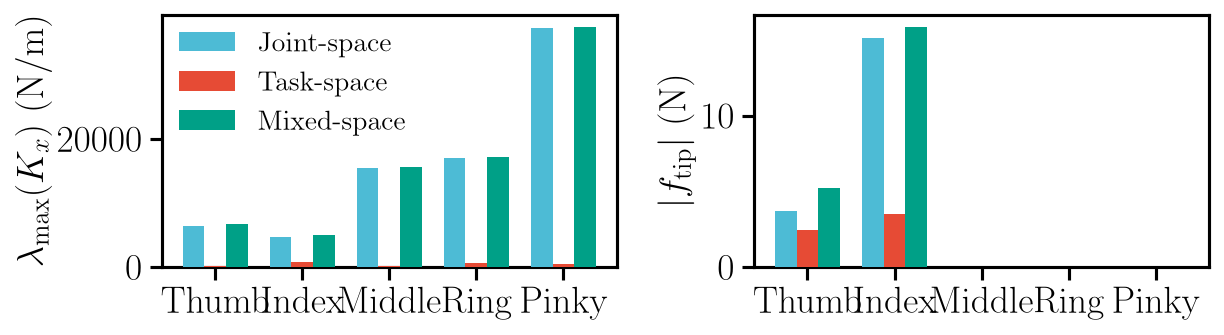

In [4]:
MODEL_NAMES  = ['JointSpace', 'TaskSpace', 'MixedSpace']
MODEL_LABELS = ['Joint-space', 'Task-space', 'Mixed-space']
MODEL_COLORS = [COLORS[0], COLORS[1], COLORS[2]]

# ---- size / aspect for THIS graph only (double panel) ----
W_IN   = 8.5 * 1.0
ASPECT = 5.15 / (8.5 * 2)
H_IN   = W_IN * ASPECT
fig, (ax_k, ax_f) = plt.subplots(1, 2, figsize=(W_IN, H_IN))

fingers_x = np.arange(len(FINGERS_ALL))
width = 0.25
offsets = [-width, 0, width]

for i, (name, label, color, off) in enumerate(zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS, offsets)):
    # max eigenvalue (most relevant for contact)
    max_eig = [eig_results[name][f][-1] for f in FINGERS_ALL]
    # force magnitude
    fmag    = [np.linalg.norm(frc_results[name][f]) for f in FINGERS_ALL]
    ax_k.bar(fingers_x + off, max_eig, width=width, color=color, label=label, zorder=3)
    ax_f.bar(fingers_x + off, fmag,    width=width, color=color, label=label, zorder=3)

ax_k.set_xticks(fingers_x)
ax_k.set_xticklabels([f.capitalize() for f in FINGERS_ALL])
ax_k.set_ylabel(r'$\lambda_{\max}(K_x)$ (N/m)')
ax_k.legend(fontsize=plt.rcParams['legend.fontsize'])

ax_f.set_xticks(fingers_x)
ax_f.set_xticklabels([f.capitalize() for f in FINGERS_ALL])
ax_f.set_ylabel(r'$|f_{\rm tip}|$ (N)')

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'hand_tip_stiffness_force.pdf'))
plt.show()

## 2 — Finite-Difference Stiffness Validation

Relative FD residual $\|K_x\,\Delta x + \Delta f\|/\|\Delta f\|$ vs. perturbation size $\epsilon$, for thumb and index fingertips. 2nd-order (CCT) should converge as $O(\epsilon)$.

In [5]:
np.random.seed(1)
fd_results = {name: {finger: {} for finger in TEST_FINGERS} for name in MODEL_NAMES}

def _tip_pos_js(finger, q):
    rtip = model_js.rtips[finger]
    if finger == 'thumb': return FK_motor2thumbPos(q, 'IP', rtip)
    return FK_motor2fingerPos(q, finger, 'DIP', rtip)

def _tip_jac_js(finger, q):
    rtip = model_js.rtips[finger]
    if finger == 'thumb':
        return np.array(model_js.jac.get_thumb_jacobian('IP', q, rtip))
    return np.array(model_js.jac.get_finger_jacobian(finger, 'DIP', q, rtip))

for finger in TEST_FINGERS:
    # joint-space
    f0  = model_js.tip_force(finger, Q_BASE, THETA_REF_DEG, K_joint_dict)
    x0  = _tip_pos_js(finger, Q_BASE)
    J_t = _tip_jac_js(finger, Q_BASE)
    K1  = model_js.tip_stiffness(finger, Q_BASE, K_joint_dict)
    K2  = model_js.tip_stiffness(finger, Q_BASE, K_joint_dict,
                                  f_ext=f0, theta_ref_deg=THETA_REF_DEG)
    for eps in EPS_VALS:
        e1, e2 = [], []
        for _ in range(N_FD):
            v = np.random.randn(3); dq = J_t.T @ v; dq *= eps / np.linalg.norm(dq)
            dx = _tip_pos_js(finger, Q_BASE + dq) - x0
            df = model_js.tip_force(finger, Q_BASE + dq, THETA_REF_DEG, K_joint_dict) - f0
            s  = np.linalg.norm(df) + 1e-15
            e1.append(np.linalg.norm(K1 @ dx + df) / s)
            e2.append(np.linalg.norm(K2 @ dx + df) / s)
        fd_results['JointSpace'][finger][eps] = (np.mean(e1), np.mean(e2))

    # task-space
    f0  = model_ts.tip_force(finger, Q_BASE, d_ref_ts, K_task_ts)
    x0  = model_ts._pos(finger, Q_BASE)
    J_t = np.array(
        model_ts.jac.get_thumb_jacobian('IP', Q_BASE, model_ts.rattachments[finger])
        if finger == 'thumb'
        else model_ts.jac.get_finger_jacobian(finger, 'DIP', Q_BASE, model_ts.rattachments[finger])
    )
    K1  = model_ts.tip_stiffness(finger, Q_BASE, K_task_ts, d_ref_ts)
    K2  = model_ts.tip_stiffness(finger, Q_BASE, K_task_ts, d_ref_ts, f_ext=f0)
    for eps in EPS_VALS:
        e1, e2 = [], []
        for _ in range(N_FD):
            v = np.random.randn(3); dq = J_t.T @ v; dq *= eps / np.linalg.norm(dq)
            dx = model_ts._pos(finger, Q_BASE + dq) - x0
            df = model_ts.tip_force(finger, Q_BASE + dq, d_ref_ts, K_task_ts) - f0
            s  = np.linalg.norm(df) + 1e-15
            e1.append(np.linalg.norm(K1 @ dx + df) / s)
            e2.append(np.linalg.norm(K2 @ dx + df) / s)
        fd_results['TaskSpace'][finger][eps] = (np.mean(e1), np.mean(e2))

    # mixed-space
    f0  = model_ms.tip_force(finger, Q_BASE, THETA_REF_DEG, d_ref_ms, K_joint_dict, K_task_ms)
    x0  = model_ms._pos(finger, Q_BASE)
    J_t = np.array(
        model_ms.jac.get_thumb_jacobian('IP', Q_BASE, model_ms.rtips[finger])
        if finger == 'thumb'
        else model_ms.jac.get_finger_jacobian(finger, 'DIP', Q_BASE, model_ms.rtips[finger])
    )
    K1  = model_ms.tip_stiffness(finger, Q_BASE, K_joint_dict, K_task_ms)
    K2  = model_ms.tip_stiffness(finger, Q_BASE, K_joint_dict, K_task_ms,
                                  d_ref_dict=d_ref_ms, f_ext=f0)
    for eps in EPS_VALS:
        e1, e2 = [], []
        for _ in range(N_FD):
            v = np.random.randn(3); dq = J_t.T @ v; dq *= eps / np.linalg.norm(dq)
            dx = model_ms._pos(finger, Q_BASE + dq) - x0
            df = model_ms.tip_force(finger, Q_BASE + dq, THETA_REF_DEG,
                                    d_ref_ms, K_joint_dict, K_task_ms) - f0
            s  = np.linalg.norm(df) + 1e-15
            e1.append(np.linalg.norm(K1 @ dx + df) / s)
            e2.append(np.linalg.norm(K2 @ dx + df) / s)
        fd_results['MixedSpace'][finger][eps] = (np.mean(e1), np.mean(e2))

print('FD validation done.')

FD validation done.


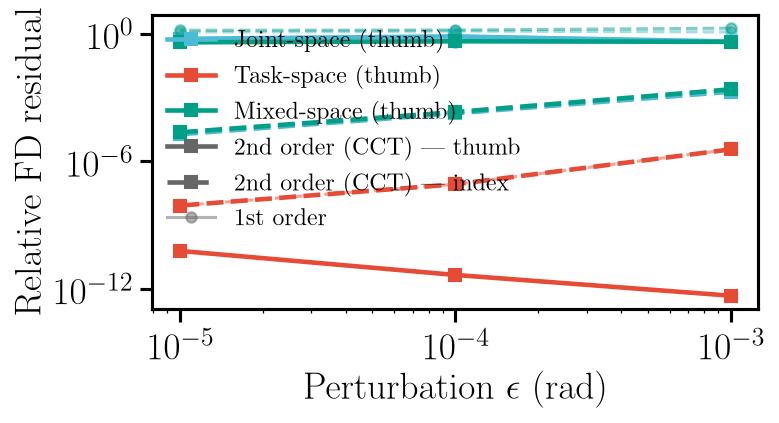

In [6]:
FINGER_LS = {'thumb': '-', 'index': '--'}

# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

for name, label, color in zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS):
    for finger in TEST_FINGERS:
        ls = FINGER_LS[finger]
        err1 = [fd_results[name][finger][e][0] for e in EPS_VALS]
        err2 = [fd_results[name][finger][e][1] for e in EPS_VALS]
        lbl2 = f'{label} ({finger})' if finger == 'thumb' else None
        ax.plot(EPS_VALS, err1, 'o' + ls, color=color, lw=1.5, ms=5, alpha=0.5)
        ax.plot(EPS_VALS, err2, 's' + ls, color=color, lw=2.2, ms=6, label=lbl2)

from matplotlib.lines import Line2D
_leg_extra = [
    Line2D([0],[0], color='0.4', ls='-',  lw=2.2, marker='s', ms=6, label='2nd order (CCT) — thumb'),
    Line2D([0],[0], color='0.4', ls='--', lw=2.2, marker='s', ms=6, label='2nd order (CCT) — index'),
    Line2D([0],[0], color='0.4', ls='-',  lw=1.5, marker='o', ms=5, alpha=0.5, label='1st order'),
]
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles=handles + _leg_extra, labels=labels_ + [h.get_label() for h in _leg_extra],
          fontsize=plt.rcParams['legend.fontsize'] - 2, loc='upper left')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Perturbation $\epsilon$ (rad)')
ax.set_ylabel('Relative FD residual')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'hand_fd_stiffness_validation.pdf'))
plt.show()

## 3 — Stiffness Gradient-Descent Convergence

Force error $\|f_{\rm meas} - f_{\rm des}\|$ vs. iteration when optimising all virtual stiffness matrices for thumb and index fingertips.

In [7]:
gd_stiff_history = {name: {finger: [] for finger in TEST_FINGERS} for name in MODEL_NAMES}

for finger in TEST_FINGERS:
    # joint-space
    K_opt = {g: K.copy() for g, K in K_joint_dict.items()}
    for i in range(MAX_ITERS):
        f_meas = model_js.tip_force(finger, Q_BASE, THETA_REF_DEG, K_opt)
        if i % LOG_EVERY == 0:
            gd_stiff_history['JointSpace'][finger].append((i, np.linalg.norm(f_meas - F_DES)))
        K_opt = model_js.stiffness_descent(finger, Q_BASE, THETA_REF_DEG, K_opt,
                                           f_meas, F_DES, lr=2e-4)
    f_final = model_js.tip_force(finger, Q_BASE, THETA_REF_DEG, K_opt)
    gd_stiff_history['JointSpace'][finger].append((MAX_ITERS, np.linalg.norm(f_final - F_DES)))
    print(f'JointSpace [{finger}] final error = {np.linalg.norm(f_final - F_DES):.6f}')

    # task-space
    K_opt = {p: K.copy() for p, K in K_task_ts.items()}
    for i in range(MAX_ITERS):
        f_meas = model_ts.tip_force(finger, Q_BASE, d_ref_ts, K_opt)
        if i % LOG_EVERY == 0:
            gd_stiff_history['TaskSpace'][finger].append((i, np.linalg.norm(f_meas - F_DES)))
        K_opt = model_ts.stiffness_descent(finger, Q_BASE, d_ref_ts, K_opt,
                                           f_meas, F_DES, lr=50)
    f_final = model_ts.tip_force(finger, Q_BASE, d_ref_ts, K_opt)
    gd_stiff_history['TaskSpace'][finger].append((MAX_ITERS, np.linalg.norm(f_final - F_DES)))
    print(f'TaskSpace [{finger}] final error  = {np.linalg.norm(f_final - F_DES):.6f}')

    # mixed-space
    Kj_opt = {g: K.copy() for g, K in K_joint_dict.items()}
    Kt_opt = {p: K.copy() for p, K in K_task_ms.items()}
    for i in range(MAX_ITERS):
        f_meas = model_ms.tip_force(finger, Q_BASE, THETA_REF_DEG, d_ref_ms, Kj_opt, Kt_opt)
        if i % LOG_EVERY == 0:
            gd_stiff_history['MixedSpace'][finger].append((i, np.linalg.norm(f_meas - F_DES)))
        Kj_opt, Kt_opt = model_ms.stiffness_descent(
            finger, Q_BASE, THETA_REF_DEG, d_ref_ms, Kj_opt, Kt_opt,
            f_meas, F_DES, lr_joint=2e-4, lr_task=1e-3)
    f_final = model_ms.tip_force(finger, Q_BASE, THETA_REF_DEG, d_ref_ms, Kj_opt, Kt_opt)
    gd_stiff_history['MixedSpace'][finger].append((MAX_ITERS, np.linalg.norm(f_final - F_DES)))
    print(f'MixedSpace [{finger}] final error  = {np.linalg.norm(f_final - F_DES):.6f}')

JointSpace [thumb] final error = 0.000000
TaskSpace [thumb] final error  = 0.000000
MixedSpace [thumb] final error  = 0.000000
JointSpace [index] final error = 0.002136
TaskSpace [index] final error  = 0.000000
MixedSpace [index] final error  = 0.017232


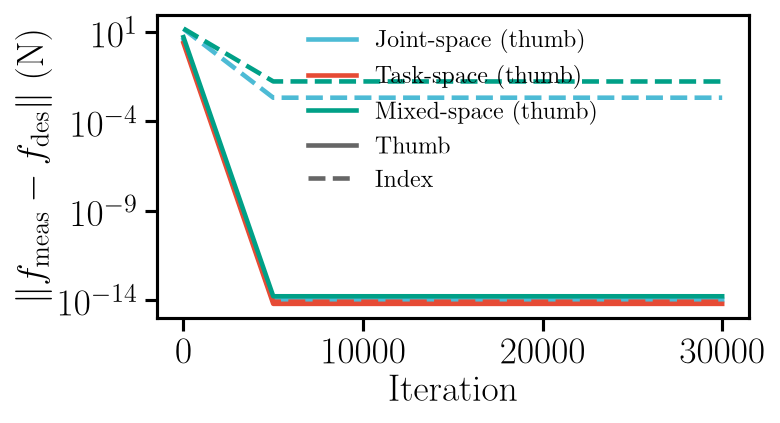

In [8]:
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

for name, label, color in zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS):
    for finger in TEST_FINGERS:
        ls = FINGER_LS[finger]
        hist = gd_stiff_history[name][finger]
        iters, errs = zip(*hist)
        lbl = f'{label} ({finger})' if finger == 'thumb' else None
        ax.semilogy(iters, errs, ls, color=color, lw=2.2, label=lbl)

# Legend for line styles
from matplotlib.lines import Line2D
_ls_leg = [
    Line2D([0],[0], color='0.4', ls='-',  lw=2.2, label='Thumb'),
    Line2D([0],[0], color='0.4', ls='--', lw=2.2, label='Index'),
]
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles=handles + _ls_leg, labels=labels_ + ['Thumb', 'Index'],
          fontsize=plt.rcParams['legend.fontsize'] - 2)

ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|f_{\rm meas} - f_{\rm des}\|$ (N)')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'hand_stiffness_descent_convergence.pdf'))
plt.show()

## 4 — Reference Gradient-Descent Convergence

Force error vs. iteration when optimising the virtual reference $\theta_{\rm ref}$ (and $d_{\rm ref}$ for task-space models) to match the desired tip force.

In [9]:
gd_ref_history = {name: {finger: [] for finger in TEST_FINGERS} for name in MODEL_NAMES}

for finger in TEST_FINGERS:
    # joint-space
    theta_opt = _build_theta_ref_deg(Q_REF, K_joint_dict).copy()
    for i in range(MAX_ITERS):
        f_meas = model_js.tip_force(finger, Q_BASE, theta_opt, K_joint_dict)
        if i % LOG_EVERY == 0:
            gd_ref_history['JointSpace'][finger].append((i, np.linalg.norm(f_meas - F_DES)))
        theta_opt = model_js.ref_descent(finger, Q_BASE, theta_opt, K_joint_dict,
                                         f_meas, F_DES, lr=5e-4)
    f_final = model_js.tip_force(finger, Q_BASE, theta_opt, K_joint_dict)
    gd_ref_history['JointSpace'][finger].append((MAX_ITERS, np.linalg.norm(f_final - F_DES)))
    print(f'JointSpace ref_descent [{finger}] final = {np.linalg.norm(f_final - F_DES):.6f}')

    # task-space
    x_ref_opt = {p: x.copy() for p, x in d_ref_ts.items()}
    for i in range(MAX_ITERS):
        f_meas = model_ts.tip_force(finger, Q_BASE, x_ref_opt, K_task_ts)
        if i % LOG_EVERY == 0:
            gd_ref_history['TaskSpace'][finger].append((i, np.linalg.norm(f_meas - F_DES)))
        x_ref_opt = model_ts.ref_descent(finger, Q_BASE, x_ref_opt, K_task_ts,
                                         f_meas, F_DES, lr=2e-7)
    f_final = model_ts.tip_force(finger, Q_BASE, x_ref_opt, K_task_ts)
    gd_ref_history['TaskSpace'][finger].append((MAX_ITERS, np.linalg.norm(f_final - F_DES)))
    print(f'TaskSpace ref_descent [{finger}] final  = {np.linalg.norm(f_final - F_DES):.6f}')

    # mixed-space
    theta_opt_ms = _build_theta_ref_deg(Q_REF, K_joint_dict).copy()
    d_ref_opt_ms = {p: x.copy() for p, x in d_ref_ms.items()}
    for i in range(MAX_ITERS):
        f_meas = model_ms.tip_force(finger, Q_BASE, theta_opt_ms, d_ref_opt_ms,
                                    K_joint_dict, K_task_ms)
        if i % LOG_EVERY == 0:
            gd_ref_history['MixedSpace'][finger].append((i, np.linalg.norm(f_meas - F_DES)))
        theta_opt_ms, d_ref_opt_ms = model_ms.ref_descent(
            finger, Q_BASE, theta_opt_ms, d_ref_opt_ms, K_joint_dict, K_task_ms,
            f_meas, F_DES, lr_joint=3.33e-05, lr_task=4.18e-08)
    f_final = model_ms.tip_force(finger, Q_BASE, theta_opt_ms, d_ref_opt_ms,
                                 K_joint_dict, K_task_ms)
    gd_ref_history['MixedSpace'][finger].append((MAX_ITERS, np.linalg.norm(f_final - F_DES)))
    print(f'MixedSpace ref_descent [{finger}] final  = {np.linalg.norm(f_final - F_DES):.6f}')

JointSpace ref_descent [thumb] final = 0.000000
TaskSpace ref_descent [thumb] final  = 0.000000
MixedSpace ref_descent [thumb] final  = 0.000000
JointSpace ref_descent [index] final = 0.000000
TaskSpace ref_descent [index] final  = 0.000000
MixedSpace ref_descent [index] final  = 0.000000


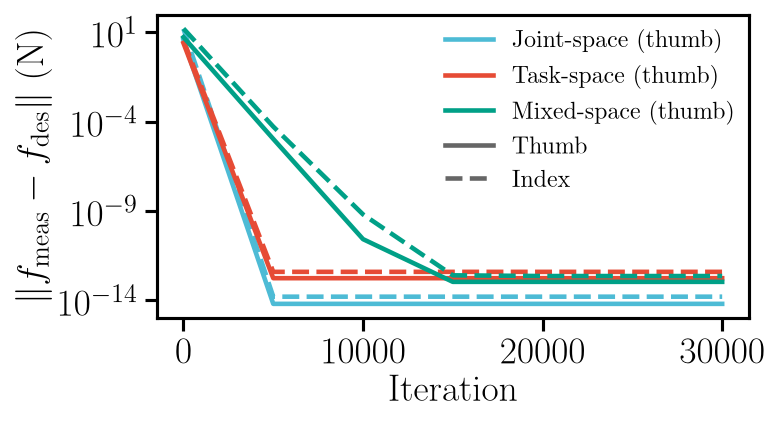

In [10]:
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

for name, label, color in zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS):
    for finger in TEST_FINGERS:
        ls = FINGER_LS[finger]
        hist = gd_ref_history[name][finger]
        iters, errs = zip(*hist)
        lbl = f'{label} ({finger})' if finger == 'thumb' else None
        ax.semilogy(iters, errs, ls, color=color, lw=2.2, label=lbl)

from matplotlib.lines import Line2D
_ls_leg = [
    Line2D([0],[0], color='0.4', ls='-',  lw=2.2, label='Thumb'),
    Line2D([0],[0], color='0.4', ls='--', lw=2.2, label='Index'),
]
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles=handles + _ls_leg, labels=labels_ + ['Thumb', 'Index'],
          fontsize=plt.rcParams['legend.fontsize'] - 2)

ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|f_{\rm meas} - f_{\rm des}\|$ (N)')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'hand_ref_descent_convergence.pdf'))
plt.show()

## 5 — Stiffness Inversion Accuracy

Frobenius-norm reconstruction error $\|K_{\rm recon} - K_{\rm des}\|_F$ from minimum-norm pseudo-inversion of the stiffness map, for thumb and index.

In [11]:
inv_errors = {name: {finger: None for finger in TEST_FINGERS} for name in MODEL_NAMES}

K_SCALE = 1.2  # scale factor to make the target different from the initial guess

for finger in TEST_FINGERS:
    # joint-space
    K_target    = {g: K.copy() * K_SCALE for g, K in K_joint_dict.items()}
    K_des_stiff = model_js.tip_stiffness(finger, Q_BASE, K_target)
    K_ff_dict   = model_js.stiffness_inversion_all(finger, Q_BASE, K_joint_dict, K_des_stiff)
    K_recon     = model_js.tip_stiffness(finger, Q_BASE, K_ff_dict)
    inv_errors['JointSpace'][finger] = np.linalg.norm(K_recon - K_des_stiff, 'fro')

    # task-space
    K_target_ts  = {p: K.copy() * K_SCALE for p, K in K_task_ts.items()}
    K_des_stiff  = model_ts.tip_stiffness(finger, Q_BASE, K_target_ts, d_ref_ts)
    K_ff_ts_dict = model_ts.stiffness_inversion_all(finger, Q_BASE, K_task_ts, K_des_stiff)
    K_recon      = model_ts.tip_stiffness(finger, Q_BASE, K_ff_ts_dict, d_ref_ts)
    inv_errors['TaskSpace'][finger] = np.linalg.norm(K_recon - K_des_stiff, 'fro')

    # mixed-space
    Kj_target   = {g: K.copy() * K_SCALE for g, K in K_joint_dict.items()}
    Kt_target   = {p: K.copy() * K_SCALE for p, K in K_task_ms.items()}
    K_des_stiff = model_ms.tip_stiffness(finger, Q_BASE, Kj_target, Kt_target)
    Kj_ff, Kt_ff = model_ms.stiffness_inversion_all(finger, Q_BASE,
                                                    K_joint_dict, K_task_ms, K_des_stiff)
    K_recon = model_ms.tip_stiffness(finger, Q_BASE, Kj_ff, Kt_ff)
    inv_errors['MixedSpace'][finger] = np.linalg.norm(K_recon - K_des_stiff, 'fro')

for finger in TEST_FINGERS:
    print(f'\n{finger.upper()}')
    for name in MODEL_NAMES:
        print(f'  {name}: ||K_recon - K_des||_F = {inv_errors[name][finger]:.2e}')


THUMB
  JointSpace: ||K_recon - K_des||_F = 1.88e-12
  TaskSpace: ||K_recon - K_des||_F = 6.21e-13
  MixedSpace: ||K_recon - K_des||_F = 2.80e-12

INDEX
  JointSpace: ||K_recon - K_des||_F = 1.03e-11
  TaskSpace: ||K_recon - K_des||_F = 1.25e-12
  MixedSpace: ||K_recon - K_des||_F = 1.10e-11


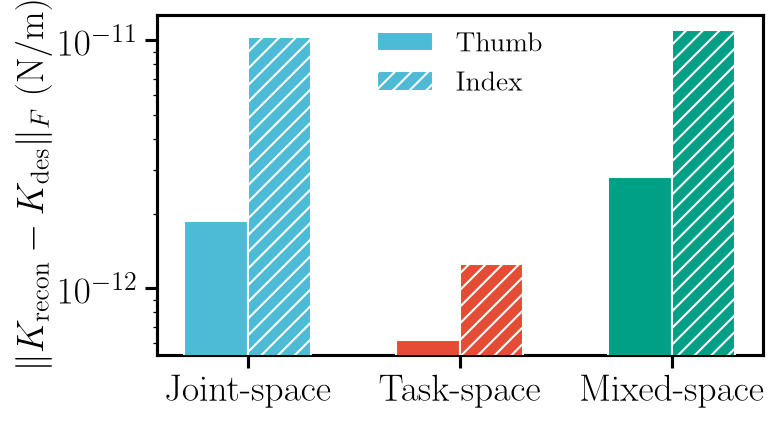

In [12]:
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

n_models  = len(MODEL_NAMES)
n_fingers = len(TEST_FINGERS)
width     = 0.3
offsets   = np.linspace(-(n_fingers - 1) * width / 2,
                         (n_fingers - 1) * width / 2, n_fingers)
x_pos = np.arange(n_models)

HATCH = {'thumb': '', 'index': '///'}
for j, finger in enumerate(TEST_FINGERS):
    errs = [inv_errors[name][finger] for name in MODEL_NAMES]
    bars = ax.bar(x_pos + offsets[j], errs, width=width,
                  color=MODEL_COLORS[:n_models],
                  hatch=HATCH[finger], edgecolor='white',
                  label=finger.capitalize(), zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(MODEL_LABELS)
ax.set_ylabel(r'$\|K_{\rm recon} - K_{\rm des}\|_F$ (N/m)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation())
ax.legend(fontsize=plt.rcParams['legend.fontsize'])
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'hand_stiffness_inversion_accuracy.pdf'))
plt.show()